In [1]:
import os
try:
    import google.colab
    print("Running in Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/dugout-prophet')
    os.system('pip install pybaseball')
except ImportError:
    print("Not in Google Colab")

Not in Google Colab


In [2]:
# Check for local CSV; if missing, download from Firebase using pyasebase/pyrebase
import os
import pandas as pd
from pybaseball import batting_stats
import numpy as np
from src.mvt_batter_model import MVTBatterModel, MVTBatterDataset, MVTBatterPredictionDataset
csv_path = "./data/batting_stats.csv"

if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    data = pd.read_csv(csv_path)

else:
    print(f"{csv_path} not found — attempting to download using pybaseball.")
    qual = 50
    start_season = 2015
    end_season = 2025
    data = batting_stats(start_season=start_season, end_season=end_season, qual=qual)
    data.to_csv('./data/batting_stats.csv', index=False)


Found ./data/batting_stats.csv, reading into DataFrame.


In [3]:
score_map = {
    'R': 0.75,
    '1B': 1,
    '2B': 1.5,
    '3B': 2,
    'HR': 3,
    'RBI': 0.75,
    'BB':1, 
    'SO':-0.5,
    'HBP': 1,
    'SB': 1,
    'CS': -2,
    'GDP': -2,
}

In [4]:
# Process data for 3D tensor - organized by player-season combination
import torch
import numpy as np
import pandas as pd

# Select relevant columns
aux_features = [
    'PA', 
    'AB', 
    'xwOBA', 
    'OPS',
    'ISO',
    'OBP',

    'O-Swing%',
    'Z-Swing%',
    'Swing%',
    'O-Contact%',
    'Z-Contact%',
    'Contact%',
    'Zone%',
    'SwStr%',
    'BsR',
    'LD%', 'GB%', 'FB%', 'HR/FB', 'Hard%', 'GB/FB','Barrel%'
 ]
features = list(score_map.keys()) + aux_features

# Qualification parameter: minimum IP in target season to include in training set
min_qual_pa = 50  # Set to > 0 to filter by innings pitched (e.g., 50 for minimum 50 IP)

# Ensure data has the necessary columns
required_cols = features + ['IDfg', 'Season']
data_processed = data.reindex(columns=[c for c in data.columns if c in required_cols]).fillna(0)


In [5]:
mvt_dataset = MVTBatterDataset(data_processed, features=features, player_col='IDfg', season_col='Season',)
X = mvt_dataset.sequences
y_features = mvt_dataset.targets_features
metadata_df = mvt_dataset.metadata_df

print(f"Tensor shape: {X.shape}")
print(f"Features target shape: {y_features.shape}")
print(f"Metadata rows: {len(metadata_df)}")
print(f"Qualification filter: min_qual_pa = {min_qual_pa}")
print(f"\nFirst few metadata entries:")
print(metadata_df.head())
print(f"\nSample sequence for entry 0:\n{X[0]}")
print(f"Corresponding features: {y_features[0]}")


Tensor shape: torch.Size([4325, 5, 34])
Features target shape: torch.Size([4325, 34])
Metadata rows: 4325
Qualification filter: min_qual_pa = 50

First few metadata entries:
                         current_season  target_pa
player_id target_season                           
375       2016                     2015       65.0
393       2016                     2015      610.0
          2017                     2016      435.0
          2018                     2017      508.0
454       2016                     2015      259.0

Sample sequence for entry 0:
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0

In [6]:
# Initialize the multihead transformer model
num_features = len(features)
nlookbacks = 3  # Number of seasons to look back for prediction

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np


def prepare_data(X, y_features, features_list, test_size=0.2, batch_size=32, store_scaler_path='./scaler.pkl'):
    """
    Prepare data for training: normalize, split, and create DataLoaders.
    Stores the scaler for later use on prediction data.
    
    Args:
        X: Tensor of shape (num_sequences, seq_len, num_features)
        y_features: Tensor of shape (num_sequences, num_features) - predicted feature values
        features_list: List of feature names for normalization tracking
        test_size: Proportion of data for validation
        batch_size: Batch size for DataLoaders
        store_scaler_path: Path to save the fitted scaler
    
    Returns:
        train_loader, val_loader, scaler, feature_stats, device
        where feature_stats is a dict of {'name': (mean, std)} for each feature
    """
    import pickle
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Normalize features across all sequences
    X_np = X.cpu().numpy()  # (num_sequences, seq_len, num_features)
    num_sequences, seq_len, num_features = X_np.shape
    
    # Reshape for scaling: (num_sequences * seq_len, num_features)
    X_reshaped = X_np.reshape(-1, num_features)
    
    # Fit scaler on training data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_reshaped)
    
    # Save scaler
    with open(store_scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {store_scaler_path}")
    
    # Reshape back to original dimensions
    X_scaled = X_scaled.reshape(num_sequences, seq_len, num_features)
    X_scaled = torch.tensor(X_scaled, dtype=torch.float32)
    
    # Normalize feature targets
    y_features_np = y_features.cpu().numpy() if isinstance(y_features, torch.Tensor) else y_features
    
    feature_stats = {}
    y_features_normalized_list = []
    
    for i, feature_name in enumerate(features_list):
        feature_values = y_features_np[:, i]
        feature_mean = np.mean(feature_values)
        feature_std = np.std(feature_values)
        feature_stats[feature_name] = (feature_mean, feature_std)
        
        normalized = (feature_values - feature_mean) / (feature_std + 1e-8)
        y_features_normalized_list.append(normalized)
    
    y_features_normalized = np.array(y_features_normalized_list).T  # (num_sequences, num_features)
    y_features_normalized = torch.tensor(y_features_normalized, dtype=torch.float32)
    
    # Train-validation split
    X_train, X_val, y_features_train, y_features_val,  = train_test_split(
        X_scaled, y_features_normalized, test_size=test_size, random_state=42
    )
    
    # Create datasets with all targets
    train_dataset = TensorDataset(
        X_train.to(device), 
        y_features_train.to(device),
    )
    val_dataset = TensorDataset(
        X_val.to(device), 
        y_features_val.to(device),
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, scaler, feature_stats,  device


def train_model(model, train_loader, val_loader, features_list, num_epochs=100, learning_rate=1e-3, 
                patience=15, device='cpu' ):
    """
    Train transformer model with all feature outputs and WAR with early stopping and learning rate scheduler.
    WAR loss is weighted higher since WAR depends on all predicted features.
    
    Args:
        model: MultiVariateTransformer model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        features_list: List of feature names being predicted
        num_epochs: Maximum number of epochs
        learning_rate: Initial learning rate
        patience: Number of epochs without improvement before early stopping
        device: Device to train on
        feature_weight: Weight for each feature loss
    
    Returns:
        model, train_losses, val_losses, best_epoch
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0
    num_features = len(features_list)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_features_batch in train_loader:
            optimizer.zero_grad()
            feature_preds = model(X_batch)
            
            # Combined loss: weighted sum of feature losses and WAR loss
            # Equal weight for each feature combined
            features_loss = criterion(feature_preds, y_features_batch)
            loss = features_loss
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_features_batch in val_loader:
                feature_preds = model(X_batch)
                
                features_loss = criterion(feature_preds, y_features_batch)
                loss = features_loss 
                
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_epoch = epoch
            torch.save(model.state_dict(), './results/batter/best_model.pt')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load('./results/batter/best_model.pt'))
            break
    
    return model, train_losses, val_losses, best_epoch


def plot_losses(train_losses, val_losses, title='Training and Validation Losses'):
    """
    Plot training and validation losses.
    
    Args:
        train_losses: List of training losses
        val_losses: List of validation losses
        title: Plot title
    """
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Initialize model with num_features parameter
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = MVTBatterModel(
    input_dim=num_features,
    num_features=num_features,
    d_model=64,
    nhead=4,  # 4 attention heads
    num_layers=2,  # 2 transformer layers
    dim_feedforward=256,
    dropout=0.1,
    nlookbacks=nlookbacks
)

print(f"Model initialized on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Predicting {len(features)} features + WAR")
print(model)


Model initialized on device: mps
Total parameters: 127,586
Predicting 34 features + WAR
MVTBatterModel(
  (input_projection): Linear(in_features=34, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Dr

In [8]:
# Prepare data and save scaler
train_loader, val_loader, scaler, feature_stats, device = prepare_data(
    X, y_features, features, batch_size=32
)

print(f"\nFeature Statistics (Mean, Std):")
for feature_name, (mean, std) in feature_stats.items():
    print(f"  {feature_name}: ({mean:.4f}, {std:.4f})")

# Train model with early stopping
model, train_losses, val_losses, best_epoch = train_model(
    model, train_loader, val_loader, features,
    num_epochs=100, 
    learning_rate=1e-3, 
    patience=20, 
    device=device,
)

print(f"Best epoch: {best_epoch + 1}")

# Plot losses
plot_losses(train_losses, val_losses, title='Transformer Model - Training and Validation Losses')

# Make predictions on validation set
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model.eval()
feature_predictions = []
feature_actuals = []

with torch.no_grad():
    for inputs, targets_features in val_loader:
        feature_preds = model(inputs)
        feature_predictions.extend(feature_preds.cpu().numpy())
        feature_actuals.extend(targets_features.cpu().numpy())

feature_predictions = np.array(feature_predictions)  # (num_val, num_features)
feature_actuals = np.array(feature_actuals)  # (num_val, num_features)

# Denormalize predictions and actuals for interpretability
feature_predictions_denorm = np.zeros_like(feature_predictions)
feature_actuals_denorm = np.zeros_like(feature_actuals)

for i, feature_name in enumerate(features):
    mean, std = feature_stats[feature_name]
    feature_predictions_denorm[:, i] = feature_predictions[:, i] * std + mean
    feature_actuals_denorm[:, i] = feature_actuals[:, i] * std + mean

# Per-feature metrics
print(f"\nPer-Feature Validation Metrics (denormalized):")
for i, feature_name in enumerate(features):
    mae = mean_absolute_error(feature_actuals_denorm[:, i], feature_predictions_denorm[:, i])
    r2 = r2_score(feature_actuals[:, i], feature_predictions[:, i])
    print(f"  {feature_name} - MAE: {mae:.4f}, R²: {r2:.4f}")

# Plot predictions vs actuals for select features
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i in range(min(16, len(features))):
    ax = axes[i]
    ax.scatter(feature_actuals_denorm[:, i], feature_predictions_denorm[:, i], alpha=0.5, s=20)
    min_val = min(feature_actuals_denorm[:, i].min(), feature_predictions_denorm[:, i].min())
    max_val = max(feature_actuals_denorm[:, i].max(), feature_predictions_denorm[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{features[i]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\nModel and scaler saved for predictions")


Scaler saved to ./scaler.pkl

Feature Statistics (Mean, Std):
  R: (42.1269, 28.8953)
  1B: (49.7919, 32.5630)
  2B: (15.5563, 10.8945)
  3B: (1.3681, 1.8420)
  HR: (11.3440, 10.1480)
  RBI: (40.5734, 28.9225)
  BB: (29.8897, 22.4380)
  SO: (75.4307, 43.6994)
  HBP: (3.7281, 3.8808)
  SB: (5.1910, 7.7236)
  CS: (1.6638, 2.2236)
  GDP: (6.6012, 5.1795)
  PA: (347.2365, 199.6178)
  AB: (310.2411, 177.8249)
  xwOBA: (0.3065, 0.0486)
  OPS: (0.6998, 0.1354)
  ISO: (0.1536, 0.0648)
  OBP: (0.3080, 0.0504)
  O-Swing%: (0.3146, 0.0641)
  Z-Swing%: (0.6822, 0.0637)
  Swing%: (0.4724, 0.0523)
  O-Contact%: (0.6181, 0.0988)
  Z-Contact%: (0.8511, 0.0564)
  Contact%: (0.7634, 0.0666)
  Zone%: (0.4297, 0.0304)
  SwStr%: (0.1123, 0.0358)
  BsR: (-0.0335, 2.1134)
  LD%: (0.2032, 0.0402)
  GB%: (0.4325, 0.0801)
  FB%: (0.3644, 0.0779)
  HR/FB: (0.1197, 0.0706)
  Hard%: (0.3208, 0.0720)
  GB/FB: (0.0133, 0.0091)
  Barrel%: (0.0708, 0.0437)


RuntimeError: The size of tensor a (5) must match the size of tensor b (3) at non-singleton dimension 1

In [ ]:
pred_season = 2025

mvt_pred_dataset = MVTBatterPredictionDataset(
    features=features,
    data = data,
    nlookbacks=nlookbacks,
    pred_season = pred_season
)

X_pred = mvt_pred_dataset.pred_sequences
pred_metadata_df = mvt_pred_dataset.pred_metadata

print(f"Prediction set size: {X_pred.shape}")
print(f"Number of players with {pred_season} data: {len(pred_metadata_df)}")
print(f"\nFirst few prediction metadata entries:")
print(pred_metadata_df.head())


Prediction set size: torch.Size([537, 5, 34])
Number of players with 2025 data: 537

First few prediction metadata entries:
           prediction_season
player_id                   
2396                    2025
2967                    2025
4940                    2025
4949                    2025
5235                    2025


PREDICTING 2026 VALUES FOR 2025 SEASON DATA

2026 Predictions for 537 players

Top 20 predicted WAR leaders for 2026:

Prediction Statistics:
  R: mean=39.0896, min=9.9768, max=117.0460
  1B: mean=45.4409, min=6.0743, max=120.4009
  2B: mean=13.9460, min=2.4576, max=38.3877
  3B: mean=1.1925, min=-0.0157, max=9.4158
  HR: mean=10.3419, min=1.5947, max=46.8293
  RBI: mean=36.9703, min=7.3746, max=115.3106
  BB: mean=27.9039, min=7.5182, max=113.1315
  SO: mean=73.5842, min=31.8446, max=165.3073
  HBP: mean=3.6994, min=0.1810, max=15.1528
  SB: mean=5.1991, min=-0.8169, max=35.2543
  CS: mean=1.6741, min=-0.3623, max=7.9247
  GDP: mean=5.7643, min=0.6812, max=17.0435
  PA: mean=325.7072, min=80.5150, max=725.8420
  AB: mean=290.9754, min=72.8450, max=647.3989
  xwOBA: mean=0.3040, min=0.2197, max=0.4699
  OPS: mean=0.6885, min=0.4960, max=1.0897
  ISO: mean=0.1508, min=0.0681, max=0.3270
  OBP: mean=0.3044, min=0.2170, max=0.4434
  O-Swing%: mean=0.3120, min=0.2017, max=0.4723
  Z-Swing%

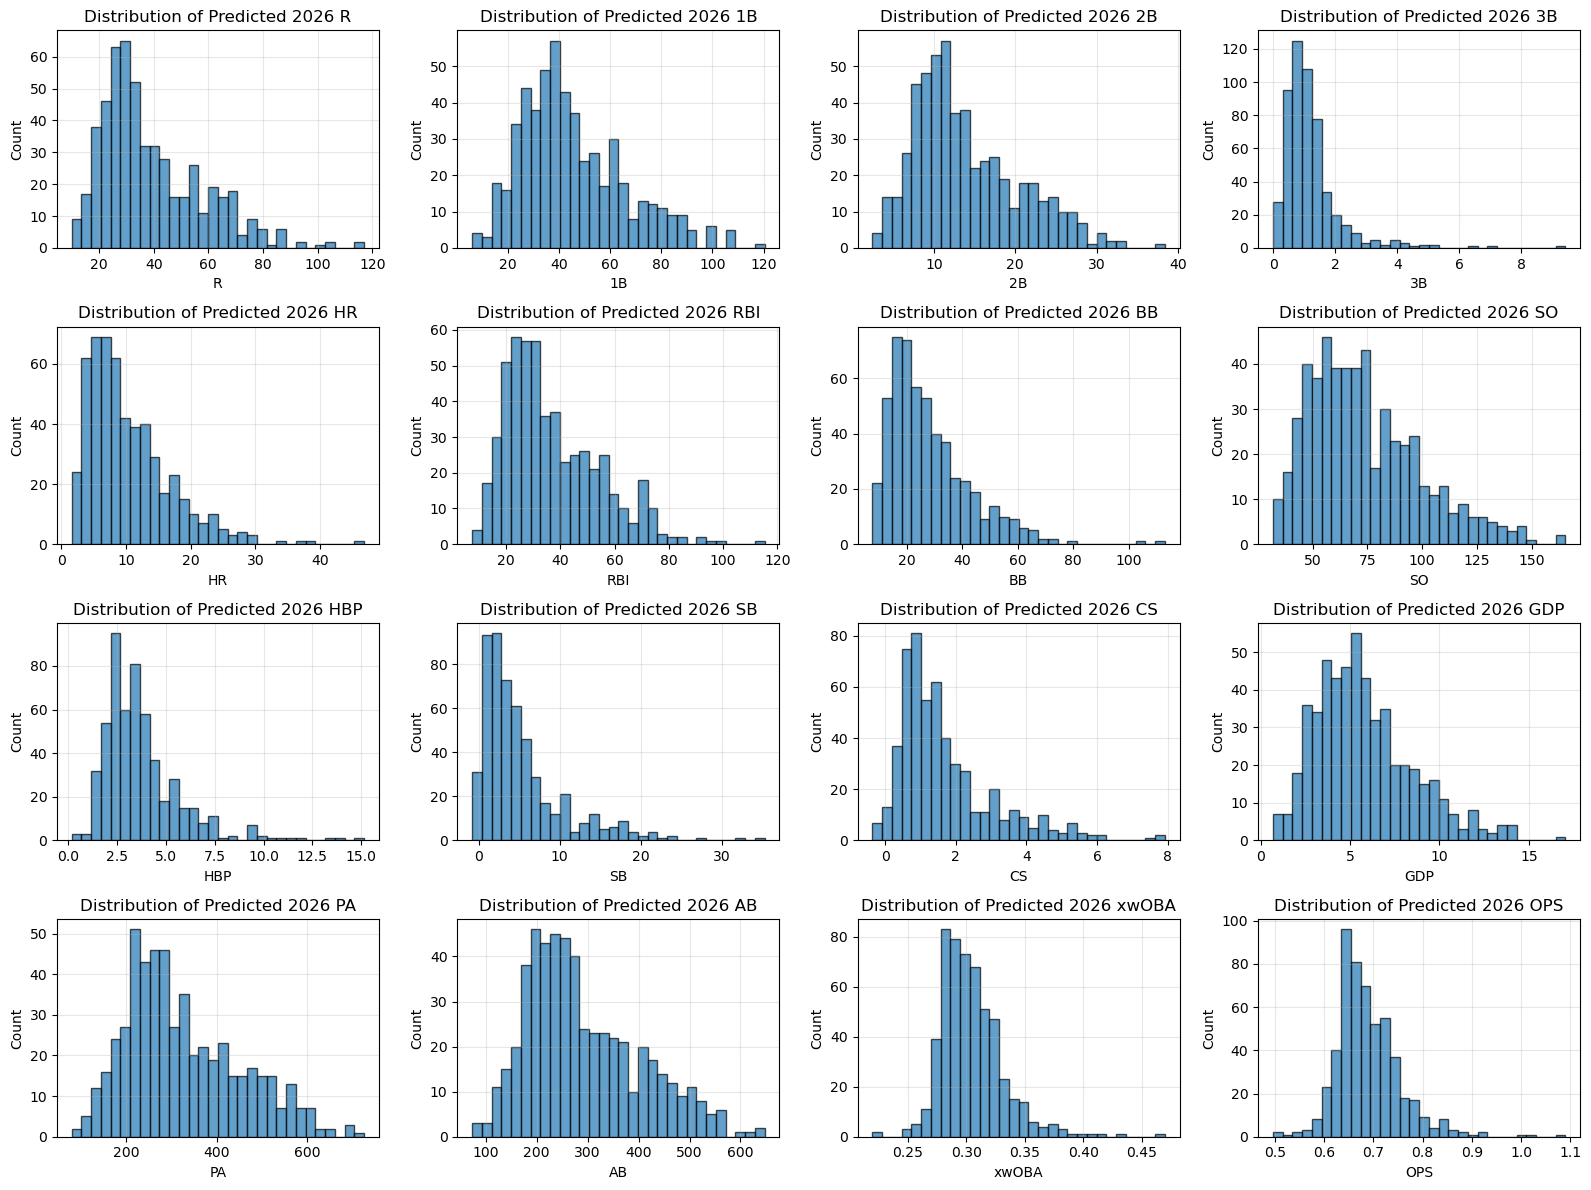

In [ ]:
# Predict 2026 WAR using 2025 data
print("="*60)
print("PREDICTING 2026 VALUES FOR 2025 SEASON DATA")
print("="*60)

# Prepare prediction data with scaler normalization
X_pred_np = X_pred.cpu().numpy()
num_pred_sequences, pred_seq_len, pred_num_features = X_pred_np.shape

# Reshape for scaling
X_pred_reshaped = X_pred_np.reshape(-1, pred_num_features)

# Apply the stored scaler
X_pred_scaled = scaler.transform(X_pred_reshaped)
X_pred_scaled = X_pred_scaled.reshape(num_pred_sequences, pred_seq_len, pred_num_features)
X_pred_scaled = torch.tensor(X_pred_scaled, dtype=torch.float32).to(device)

# Make predictions
model.eval()
feature_preds_2026 = []

with torch.no_grad():
    for i in range(0, X_pred_scaled.shape[0], 32):  # Process in batches
        batch_end = min(i + 32, X_pred_scaled.shape[0])
        X_batch = X_pred_scaled[i:batch_end]
        feature_pred = model(X_batch)
        feature_preds_2026.extend(feature_pred.cpu().numpy())

feature_preds_2026 = np.array(feature_preds_2026)  # (num_players, num_features)

# Denormalize all predictions
feature_preds_2026_denorm = np.zeros_like(feature_preds_2026)
for i, feature_name in enumerate(features):
    mean, std = feature_stats[feature_name]
    feature_preds_2026_denorm[:, i] = feature_preds_2026[:, i] * std + mean


# Create results dataframe with all predicted features
results_df = pred_metadata_df.copy()
for i, feature_name in enumerate(features):
    results_df[f'predicted_{feature_name}_2026'] = feature_preds_2026_denorm[:, i]

# Reset index to make player_id a column for better readability
results_df = results_df.reset_index()

print(f"\n2026 Predictions for {len(results_df)} players")
print(f"\nTop 20 predicted WAR leaders for 2026:")
display_cols = ['player_id', 'predicted_IP_2026', 'predicted_CSW%_2026', 'predicted_war_2026']

print(f"\nPrediction Statistics:")
for i, feature_name in enumerate(features):
    print(f"  {feature_name}: mean={feature_preds_2026_denorm[:, i].mean():.4f}, min={feature_preds_2026_denorm[:, i].min():.4f}, max={feature_preds_2026_denorm[:, i].max():.4f}")

# Save predictions to CSV
results_df.to_csv('./results/batter/2026_predictions.csv', index=False)
print(f"\nPredictions saved to ./results/batter/2026_predictions.csv")

# Plot distributions of predicted 2026 features
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(min(16, len(features))):
    ax = axes[i]
    ax.hist(feature_preds_2026_denorm[:, i], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(features[i])
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of Predicted 2026 {features[i]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
pd.set_option('display.max_rows', 100)
csv_path = "./results/batter/2026_predictions.csv"
if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    results_df = pd.read_csv(csv_path)

data_2025 = data[data['Season'] == 2025]
results_with_name = results_df.merge(data_2025[['IDfg','Name',]], left_on=['player_id'], right_on=['IDfg'], how='left')

Found ./results/batter/2026_predictions.csv, reading into DataFrame.


In [ ]:
results_with_name['predicted_points_2026'] = 0
for key, value in score_map.items():
     results_with_name['predicted_points_2026'] += results_with_name[f'predicted_{key}_2026'] * value

In [ ]:
results_with_name.sort_values('predicted_points_2026', ascending=False).head(100)[['Name', 'IDfg', 'predicted_points_2026', ]]

,Name,IDfg,predicted_points_2026
92,Aaron Judge,15640,469.830326
366,Bobby Witt Jr.,25764,434.035234
228,Juan Soto,20123,407.720977
203,Shohei Ohtani,19755,392.315441
409,Elly De La Cruz,26668,374.434407
303,Geraldo Perdomo,22799,349.522070
373,Corbin Carroll,25878,346.634868
344,Brendan Donovan,24679,331.665039
151,Kyle Tucker,18345,327.282567
339,Steven Kwan,24610,323.574133
